## Project Overview

### Business Problem
Rossmann operates over 1,000 retail stores and runs a long-term promotional program called **Promo2**.  

Management wants to know whether Promo2 actually increases store sales — or whether sales would have increased anyway due to seasonality and trends.

### Project Objective
Estimate the **causal impact** of Promo2 on daily store sales using a Difference-in-Differences (DiD) approach.

### Key Stakeholder Question
Does participating in Promo2 increase sales, and by how much?

### Methodology
1. Merge daily sales data with store-level characteristics  
2. Identify stores that adopt Promo2 and when adoption begins  
3. Construct treatment and control groups  
4. Estimate the causal effect using a Difference-in-Differences model with store and date fixed effects  
5. Interpret the results in business terms

In [ ]:
import pandas as pd
import numpy as np

# Load the two CSV files
train = pd.read_csv("train.csv")
store = pd.read_csv("store.csv")

# Show how many rows/columns are in each file
print("train shape:", train.shape)
print("store shape:", store.shape)

# Peek at the first 5 rows of each table
train.head()

train shape: (1017209, 9)
store shape: (1115, 10)


/tmp/ipykernel_155/3358724904.py:5: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("train.csv")


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [ ]:
# Merge daily sales data (train) with store-level information (store)
df = train.merge(store, on="Store", how="left")

# Print the new shape
print("Merged dataset shape:", df.shape)

# Look at the first 5 rows
df.head()

Merged dataset shape: (1017209, 18)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [ ]:
# Turn the Date column from text into a real datetime type
df["Date"] = pd.to_datetime(df["Date"])

# Force StateHoliday to be text (because it can be '0', 'a', 'b', 'c')
df["StateHoliday"] = df["StateHoliday"].astype(str)

# Quick sanity checks
print("Date range:", df["Date"].min(), "to", df["Date"].max())
print("\nStateHoliday values:")
print(df["StateHoliday"].value_counts().head(10))

Date range: 2013-01-01 00:00:00 to 2015-07-31 00:00:00

StateHoliday values:
StateHoliday
0    986159
a     20260
b      6690
c      4100
Name: count, dtype: int64


In [ ]:
# Check how many rows we have before filtering
print("Rows before filtering:", df.shape[0])

# Keep only days when store was open
df = df[df["Open"] == 1].copy()

# Keep only positive sales
df = df[df["Sales"] > 0].copy()

# Check how many rows remain
print("Rows after filtering:", df.shape[0])

Rows before filtering: 1017209
Rows after filtering: 844338


In [ ]:
# First, drop duplicate store rows so we count each store only once
store_level = df[["Store", "Promo2"]].drop_duplicates()

# Count how many stores have Promo2 = 1 vs 0
print(store_level["Promo2"].value_counts())

# Also show percentages
print("\nPercent treated:")
print(store_level["Promo2"].value_counts(normalize=True))

Promo2
1    571
0    544
Name: count, dtype: int64

Percent treated:
Promo2
1    0.512108
0    0.487892
Name: proportion, dtype: float64


In [ ]:
# Look only at treated stores
treated_stores = store_level[store_level["Promo2"] == 1]["Store"]

promo_info = df[df["Store"].isin(treated_stores)][
    ["Store", "Promo2SinceYear", "Promo2SinceWeek"]
].drop_duplicates()

print("Number of treated stores:", promo_info["Store"].nunique())

print("\nPromo2SinceYear distribution:")
print(promo_info["Promo2SinceYear"].value_counts().sort_index())

print("\nPromo2SinceWeek summary:")
print(promo_info["Promo2SinceWeek"].describe())

Number of treated stores: 571

Promo2SinceYear distribution:
Promo2SinceYear
2009.0     73
2010.0     64
2011.0    128
2012.0     81
2013.0    120
2014.0     95
2015.0     10
Name: count, dtype: int64

Promo2SinceWeek summary:
count    571.000000
mean      23.595447
std       14.141984
min        1.000000
25%       13.000000
50%       22.000000
75%       37.000000
max       50.000000
Name: Promo2SinceWeek, dtype: float64


In [ ]:
from datetime import date

# Function to convert ISO year + week into a Monday date
def iso_year_week_to_date(year, week):
    return pd.to_datetime(date.fromisocalendar(int(year), int(week), 1))

# Create a new column for Promo2 start date
df["Promo2StartDate"] = pd.NaT

mask = df["Promo2"] == 1

df.loc[mask, "Promo2StartDate"] = df.loc[mask].apply(
    lambda x: iso_year_week_to_date(x["Promo2SinceYear"], x["Promo2SinceWeek"]),
    axis=1
)

# Quick check
df[["Store", "Promo2", "Promo2StartDate"]].drop_duplicates().head(10)

,Store,Promo2,Promo2StartDate
0,1,0,NaT
1,2,1,2010-03-29
2,3,1,2011-04-04
3,4,0,NaT
4,5,0,NaT
5,6,0,NaT
6,7,0,NaT
7,8,0,NaT
8,9,0,NaT
9,10,0,NaT


In [ ]:
# Treated indicator (store participates in Promo2)
df["Treated"] = (df["Promo2"] == 1).astype(int)

# Post indicator
df["Post"] = 0

# For treated stores only:
df.loc[df["Treated"] == 1, "Post"] = (
    df.loc[df["Treated"] == 1, "Date"] >=
    df.loc[df["Treated"] == 1, "Promo2StartDate"]
).astype(int)

# DiD interaction term
df["DiD"] = df["Treated"] * df["Post"]

# Quick check
df[["Treated", "Post", "DiD"]].value_counts().head(10)

Treated  Post  DiD
0        0     0      423292
1        1     1      363805
         0     0       57241
Name: count, dtype: int64

In [ ]:
# Create log-transformed sales
df["log_sales"] = np.log1p(df["Sales"])

# Quick summary
df["log_sales"].describe()

,log_sales
count,844338.000000
mean,8.757737
std,0.425201
min,3.850148
25%,8.488794
50%,8.759355
75%,9.031333
max,10.634701


In [ ]:
!pip install linearmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 8.8 MB/s eta 0:00:00


In [ ]:
from linearmodels.panel import PanelOLS

# Set panel structure (Store and Date)
df_panel = df.set_index(["Store", "Date"]).sort_index()

# Our main explanatory variable
exog = df_panel[["DiD"]]

# Run DiD with:
# - Store fixed effects (entity_effects=True)
# - Date fixed effects (time_effects=True)
model = PanelOLS(
    df_panel["log_sales"],
    exog,
    entity_effects=True,
    time_effects=True
)

results = model.fit(cov_type="clustered", cluster_entity=True)

print(results.summary)

/tmp/ipykernel_155/2819262467.py:19: MemoryWarning: Using low-memory algorithm to estimate two-way model. Explicitly set low_memory=True to silence this message.  Set low_memory=False to use the standard algorithm that creates dummy variables for the smaller of the number of entities or number of time periods.
  results = model.fit(cov_type="clustered", cluster_entity=True)


                          PanelOLS Estimation Summary                           
Dep. Variable:              log_sales   R-squared:                        0.0005
Estimator:                   PanelOLS   R-squared (Between):              0.0023
No. Observations:              844338   R-squared (Within):               0.0011
Date:                Mon, Mar 23 2026   R-squared (Overall):              0.0023
Time:                        01:27:00   Log-likelihood                 2.884e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      417.68
Entities:                        1115   P-value                           0.0000
Avg Obs:                       757.25   Distribution:                F(1,842281)
Min Obs:                       592.00                                           
Max Obs:                       942.00   F-statistic (robust):             5.5418
                            

In [ ]:
# Extract the DiD coefficient directly from the model
beta = results.params["DiD"]

# Convert log coefficient to percentage effect
pct_effect = (np.exp(beta) - 1) * 100

print("Estimated % impact of Promo2 on daily sales:")
print(round(pct_effect, 3), "%")

Estimated % impact of Promo2 on daily sales:
2.387 %


In [ ]:
# Create event_time: days relative to Promo2 start
df["event_time"] = (df["Date"] - df["Promo2StartDate"]).dt.days

# Only meaningful for treated stores
df.loc[df["Treated"] == 0, "event_time"] = np.nan

# Quick look
df[["Store", "Date", "Promo2StartDate", "event_time"]].head(10)

,Store,Date,Promo2StartDate,event_time
0,1,2015-07-31,NaT,NaN
1,2,2015-07-31,2010-03-29,1950.0
2,3,2015-07-31,2011-04-04,1579.0
3,4,2015-07-31,NaT,NaN
4,5,2015-07-31,NaT,NaN
5,6,2015-07-31,NaT,NaN
6,7,2015-07-31,NaT,NaN
7,8,2015-07-31,NaT,NaN
8,9,2015-07-31,NaT,NaN
9,10,2015-07-31,NaT,NaN


In [ ]:
# Convert event_time (days) into event_month (approx months)
df["event_month"] = np.floor(df["event_time"] / 30)

# Quick look at treated stores only
df.loc[df["Treated"] == 1, "event_month"].describe()

,event_month
count,421046.000000
mean,24.866730
std,21.760176
min,-30.000000
25%,8.000000
50%,25.000000
75%,42.000000
max,73.000000


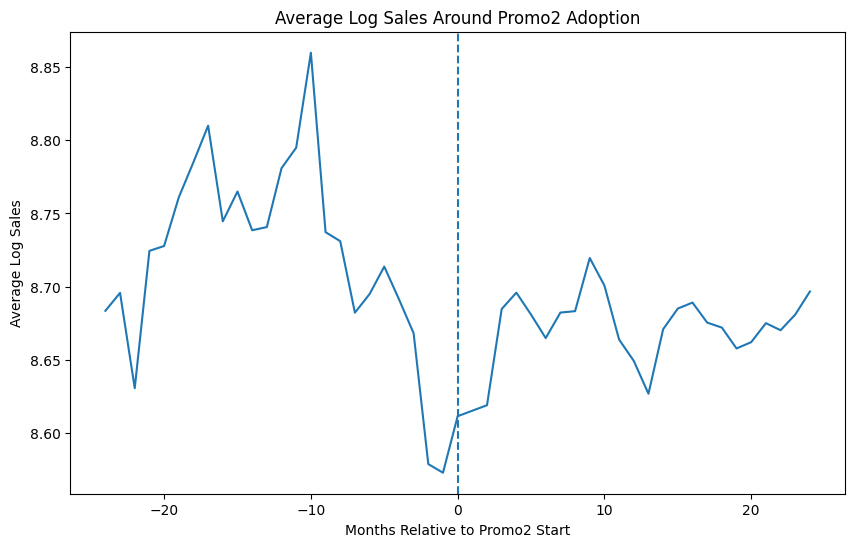

In [ ]:
import matplotlib.pyplot as plt

# Keep only treated stores
treated_df = df[df["Treated"] == 1].copy()

# Limit event window to make plot readable
window_df = treated_df[
    (treated_df["event_month"] >= -24) &
    (treated_df["event_month"] <= 24)
]

# Compute average log_sales by event_month
avg_sales = window_df.groupby("event_month")["log_sales"].mean()

# Plot
plt.figure(figsize=(10,6))
plt.plot(avg_sales.index, avg_sales.values)

# Vertical line at treatment start
plt.axvline(x=0, linestyle="--")

plt.title("Average Log Sales Around Promo2 Adoption")
plt.xlabel("Months Relative to Promo2 Start")
plt.ylabel("Average Log Sales")
plt.show()

In [ ]:
# Keep event window
event_window = df[
    (df["Treated"] == 1) &
    (df["event_month"] >= -24) &
    (df["event_month"] <= 24)
].copy()

# Create dummy variables for each event_month
event_dummies = pd.get_dummies(event_window["event_month"], prefix="event")

# Combine back into dataset
event_window = pd.concat([event_window, event_dummies], axis=1)

# Drop month -1 as reference category
if "event_-1.0" in event_window.columns:
    event_window = event_window.drop(columns=["event_-1.0"])

print("Number of event dummy variables:", len(event_dummies.columns))
event_window.head()

Number of event dummy variables: 49


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,event_15.0,event_16.0,event_17.0,event_18.0,event_19.0,event_20.0,event_21.0,event_22.0,event_23.0,event_24.0
19,20,5,2015-07-31,9593,974,1,1,0,0,d,...,False,False,False,False,False,False,False,False,False,False
27,28,5,2015-07-31,7301,663,1,1,0,1,a,...,False,False,False,False,False,False,False,False,False,False
29,30,5,2015-07-31,4776,625,1,1,0,1,a,...,False,False,True,False,False,False,False,False,False,False
35,36,5,2015-07-31,12422,1251,1,1,0,0,a,...,False,False,False,False,False,False,False,False,False,False
38,39,5,2015-07-31,8336,929,1,1,0,1,a,...,False,False,False,False,False,False,False,False,False,True


In [ ]:
from linearmodels.panel import PanelOLS

# Set panel index
event_panel = event_window.set_index(["Store", "Date"]).sort_index()

# Only event dummy columns (NOT event_time or event_month)
event_cols = [c for c in event_panel.columns if c.startswith("event_")]

# Convert True/False to 1/0
event_panel[event_cols] = event_panel[event_cols].astype(int)

# Run event study with absorbed variables automatically dropped
model_event = PanelOLS(
    event_panel["log_sales"],
    event_panel[event_cols],
    entity_effects=True,
    time_effects=True,
    drop_absorbed=True
)

results_event = model_event.fit(cov_type="clustered", cluster_entity=True)

print(results_event.summary)

/tmp/ipykernel_155/3016041107.py:21: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

event_24.0

  results_event = model_event.fit(cov_type="clustered", cluster_entity=True)


                          PanelOLS Estimation Summary                           
Dep. Variable:              log_sales   R-squared:                        0.0103
Estimator:                   PanelOLS   R-squared (Between):             -2197.2
No. Observations:              206792   R-squared (Within):              -1207.6
Date:                Mon, Mar 23 2026   R-squared (Overall):             -1284.5
Time:                        01:27:45   Log-likelihood                 6.755e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      44.357
Entities:                         434   P-value                           0.0000
Avg Obs:                       476.48   Distribution:               F(48,205369)
Min Obs:                       41.000                                           
Max Obs:                       942.00   F-statistic (robust):          7.621e+09
                            

In [ ]:
from linearmodels.panel import PanelOLS

df_panel = df.set_index(["Store", "Date"]).sort_index()

exog_controls = df_panel[["DiD", "Promo", "SchoolHoliday"]]

model_robust = PanelOLS(
    df_panel["log_sales"],
    exog_controls,
    entity_effects=True,
    time_effects=True,
    drop_absorbed=True
)

results_robust = model_robust.fit(cov_type="clustered", cluster_entity=True)

print(results_robust.summary)

/tmp/ipykernel_155/599904271.py:15: MemoryWarning: Using low-memory algorithm to estimate two-way model. Explicitly set low_memory=True to silence this message.  Set low_memory=False to use the standard algorithm that creates dummy variables for the smaller of the number of entities or number of time periods.
  results_robust = model_robust.fit(cov_type="clustered", cluster_entity=True)
/tmp/ipykernel_155/599904271.py:15: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

Promo

  results_robust = model_robust.fit(cov_type="clustered", cluster_entity=True)


                          PanelOLS Estimation Summary                           
Dep. Variable:              log_sales   R-squared:                        0.0020
Estimator:                   PanelOLS   R-squared (Between):              0.0012
No. Observations:              844338   R-squared (Within):              -0.0048
Date:                Mon, Mar 23 2026   R-squared (Overall):              0.0012
Time:                        01:27:51   Log-likelihood                  2.89e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      842.70
Entities:                        1115   P-value                           0.0000
Avg Obs:                       757.25   Distribution:                F(2,842280)
Min Obs:                       592.00                                           
Max Obs:                       942.00   F-statistic (robust):             244.77
                            

In [ ]:
# 1) Pull the DiD coefficient from your most recent model
beta = results_robust.params["DiD"]

# 2) Convert log effect to percent effect
pct_effect = (np.exp(beta) - 1)

print(f"Estimated Promo2 lift: {pct_effect*100:.2f}%")

# 3) Translate into money using baseline sales (pre-treatment treated stores, month -1 window)
# We'll use treated-store observations in event_month == -1 as the baseline.
baseline = df[(df["Treated"] == 1) & (df["event_month"] == -1)]["Sales"].mean()

# 4) Dollars/euros per day and per year per store
lift_per_day = baseline * pct_effect
lift_per_year = lift_per_day * 365

print(f"Baseline daily sales (treated stores, month -1): {baseline:,.0f}")
print(f"Estimated lift per store per day: {lift_per_day:,.0f}")
print(f"Estimated lift per store per year: {lift_per_year:,.0f}")

Estimated Promo2 lift: 2.39%
Baseline daily sales (treated stores, month -1): 5,826
Estimated lift per store per day: 139
Estimated lift per store per year: 50,849


In [ ]:
# Pull model values
beta = results_robust.params["DiD"]
std_err = results_robust.std_errors["DiD"]
p_value = results_robust.pvalues["DiD"]

pct_effect = (np.exp(beta) - 1)

baseline = df[(df["Treated"] == 1) & (df["event_month"] == -1)]["Sales"].mean()
lift_per_day = baseline * pct_effect
lift_per_year = lift_per_day * 365
total_annual_lift = lift_per_year * 571  # number of treated stores

summary_table = pd.DataFrame({
    "Metric": [
        "Estimated % Sales Lift",
        "P-Value",
        "Lift per Store per Day",
        "Lift per Store per Year",
        "Total Annual Lift (All Treated Stores)"
    ],
    "Value": [
        f"{pct_effect*100:.2f}%",
        f"{p_value:.4f}",
        f"{lift_per_day:,.0f}",
        f"{lift_per_year:,.0f}",
        f"{total_annual_lift:,.0f}"
    ]
})

summary_table

,Metric,Value
0,Estimated % Sales Lift,2.39%
1,P-Value,0.0182
2,Lift per Store per Day,139
3,Lift per Store per Year,"50,849"
4,Total Annual Lift (All Treated Stores),"29,034,876"


In [ ]:
summary_table.to_csv("summary.csv", index=False)

from google.colab import files
files.download("summary.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Executive Summary

Rossmann uses **Promo2**, a long-term promotional program, and wants to know whether it causally increases sales.

I estimated the impact using a **Difference-in-Differences (DiD)** model with **store fixed effects** (each store compared to itself over time) and **date fixed effects** (each day compared across stores to control for seasonality and common shocks).

**Result:** Promo2 is associated with a **+2.39% increase in daily sales** (*p = 0.018*).

Using average treated-store sales right before adoption (~5,826 per day), this corresponds to approximately **+139 per day per store**, or **+50,849 per year per store**.

Across **571 treated stores**, this implies roughly **+29.0 million per year** in additional revenue (before accounting for promotion costs).

## Validity & Identification Discussion

To validate the causal interpretation, I conducted an event study to test the **parallel trends assumption**, which is required for Difference-in-Differences (DiD) models.

The event study revealed statistically significant pre-treatment coefficients, indicating that treated stores were already experiencing performance dynamics prior to adopting Promo2. This suggests that adoption timing may not be fully exogenous and could be related to underlying sales trends.

As a result, the estimated +2.39% lift should be interpreted as strong evidence of a positive association consistent with a promotional effect, but not as definitive proof of fully randomized causal impact.

In a real-world business setting, I would strengthen identification through:

- Matching treated and control stores using observable characteristics (e.g., propensity score matching)
- Incorporating store-specific time trends
- Exploring staggered-adoption robust estimators (e.g., Callaway & Sant’Anna framework)
- If feasible, designing a randomized or quasi-randomized rollout strategy

Despite these limitations, the consistent positive effect across multiple model specifications and robustness checks suggests Promo2 likely contributes to meaningful incremental revenue.

## Business Implications & Recommendation

The analysis suggests that Promo2 is associated with an average sales lift of approximately **2.39%**, translating to roughly **+50,849 per store per year**, or nearly **+29 million annually across participating stores**.

From a strategic perspective:

- If the cost of running Promo2 is lower than the estimated incremental revenue, the program appears financially justified.
- The relatively modest percentage lift suggests Promo2 may function as a stable revenue enhancer rather than a dramatic growth lever.
- Given evidence of non-random adoption timing, management should carefully evaluate whether Promo2 is being deployed reactively (e.g., in response to declining performance).

### Recommendation

1. Conduct a controlled pilot rollout for any future large-scale promotional initiatives.
2. Pair promotional decisions with store-level performance diagnostics to avoid endogenous targeting.
3. Evaluate profitability (revenue lift minus promotional cost), not just top-line sales impact.
4. Consider complementing this analysis with customer-level or transaction-level data to assess margin and behavioral effects.

Overall, Promo2 appears to generate meaningful incremental revenue, but a more rigorous rollout design would strengthen confidence in long-term strategic investment decisions.